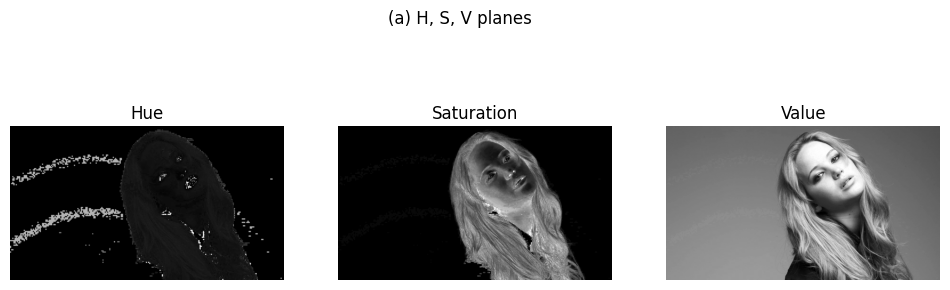

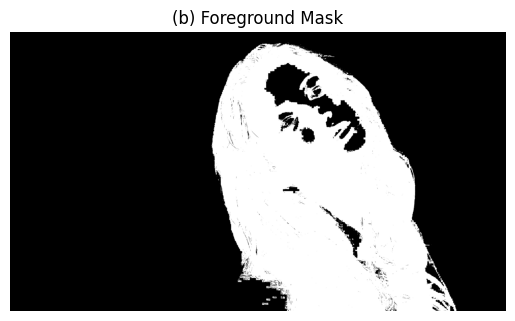

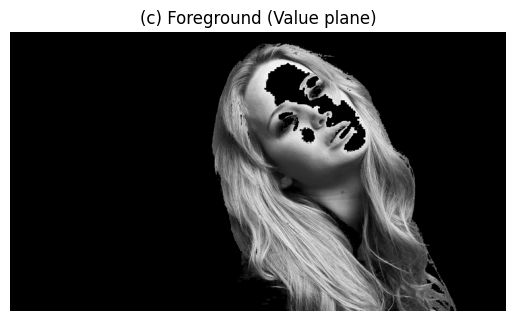

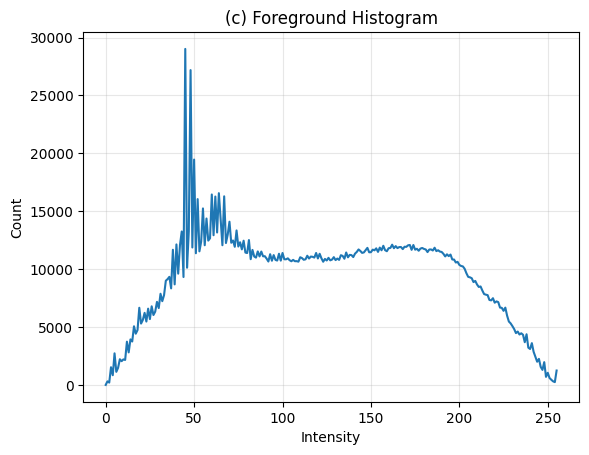

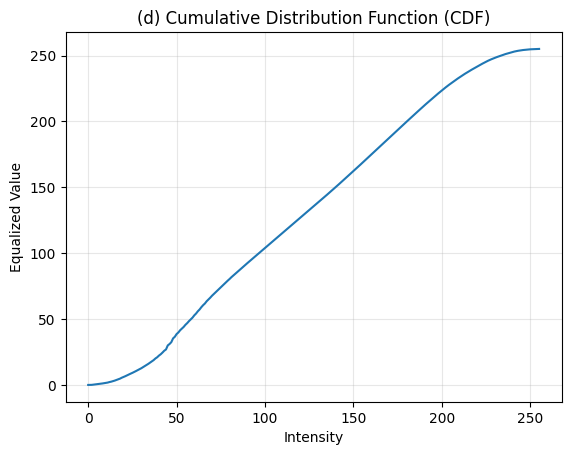

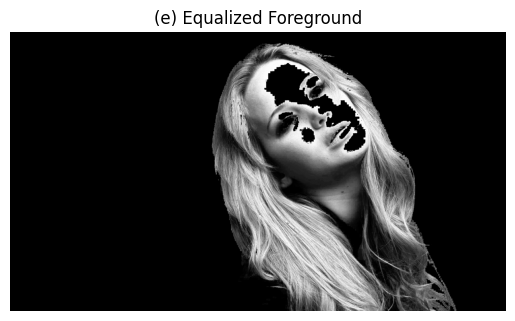

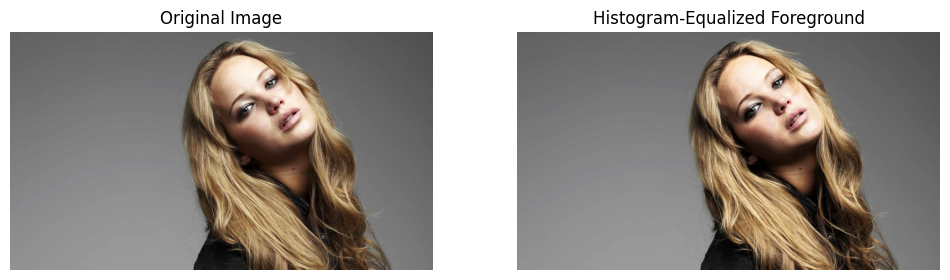

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


bgr = cv2.imread('/content/sample_data/jeniffer.jpg')
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap='gray'); plt.title("Hue"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap='gray'); plt.title("Saturation"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap='gray'); plt.title("Value"); plt.axis("off")
plt.suptitle("(a) H, S, V planes")
plt.show()


_, mask = cv2.threshold(S, 50, 255, cv2.THRESH_BINARY)

plt.figure()
plt.imshow(mask, cmap="gray")
plt.title("(b) Foreground Mask")
plt.axis("off")
plt.show()


foreground = cv2.bitwise_and(V, V, mask=mask)
plt.figure()
plt.imshow(foreground, cmap="gray")
plt.title("(c) Foreground (Value plane)")
plt.axis("off")
plt.show()

hist = cv2.calcHist([foreground],[0],mask,[256],[0,256]).ravel()

plt.figure()
plt.plot(hist)
plt.title("(c) Foreground Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

cdf = np.cumsum(hist)
cdf_norm = cdf / cdf[-1] * 255

plt.figure()
plt.plot(cdf_norm)
plt.title("(d) Cumulative Distribution Function (CDF)")
plt.xlabel("Intensity")
plt.ylabel("Equalized Value")
plt.grid(True, alpha=0.3)
plt.show()


lut = np.floor(cdf_norm).astype(np.uint8)

foreground_eq = lut[foreground]

plt.figure()
plt.imshow(foreground_eq, cmap="gray")
plt.title("(e) Equalized Foreground")
plt.axis("off")
plt.show()


background = cv2.bitwise_and(V, V, mask=cv2.bitwise_not(mask))
V_eq = cv2.add(background, foreground_eq)
hsv_eq = cv2.merge([H, S, V_eq])
bgr_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)
rgb_orig = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_eq   = cv2.cvtColor(bgr_eq, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(rgb_orig); plt.title("Original Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(rgb_eq); plt.title("Histogram-Equalized Foreground"); plt.axis("off")
plt.show()
